# 💰 Medical Insurance Cost Predictor — ML Notebook

This notebook trains a Random Forest regression model that estimates annual
medical insurance charges from patient profile data (age, sex, BMI, children,
smoker status, region).

**Dataset:** `data/insurance.csv` — 1,338 records matching the schema and
real-world statistical patterns of the widely-used Kaggle *"Medical Cost
Personal Datasets"*. This sandboxed environment doesn't have direct access to
kaggle.com, so the dataset here is synthetically generated to match that
dataset's column schema, value ranges, and well-documented cost relationships
(smoking and high BMI sharply raise charges, age raises the baseline, each
dependent adds a modest premium, region adds small variance). If you have the
original Kaggle CSV, you can drop it in at the same path — the schema is
identical and no downstream code needs to change.

> ⚠️ **Disclaimer:** Educational/demo project. Not financial or medical advice.


In [3]:
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42


## 1. Load and inspect the data

In [5]:
df = pd.read_csv("insurance.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,22,female,31.026,3,yes,northwest,41863.94393
1,54,male,17.985,2,no,southeast,15798.45466
2,48,female,34.447,1,yes,northwest,51832.38318
3,38,male,35.299,0,no,southwest,8730.21722
4,38,male,29.168,2,no,northeast,11827.54886


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.393124,30.476836,1.102392,19774.029175
std,13.534665,6.193314,1.260104,13182.498001
min,18.000000,15.900000,0.000000,3305.010450
25%,30.000000,26.411500,0.000000,11484.463972
50%,42.000000,30.722000,1.000000,15224.512530
75%,53.000000,34.560750,2.000000,19517.807350
max,64.000000,48.477000,5.000000,57798.570220


In [8]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## 2. Exploratory Data Analysis

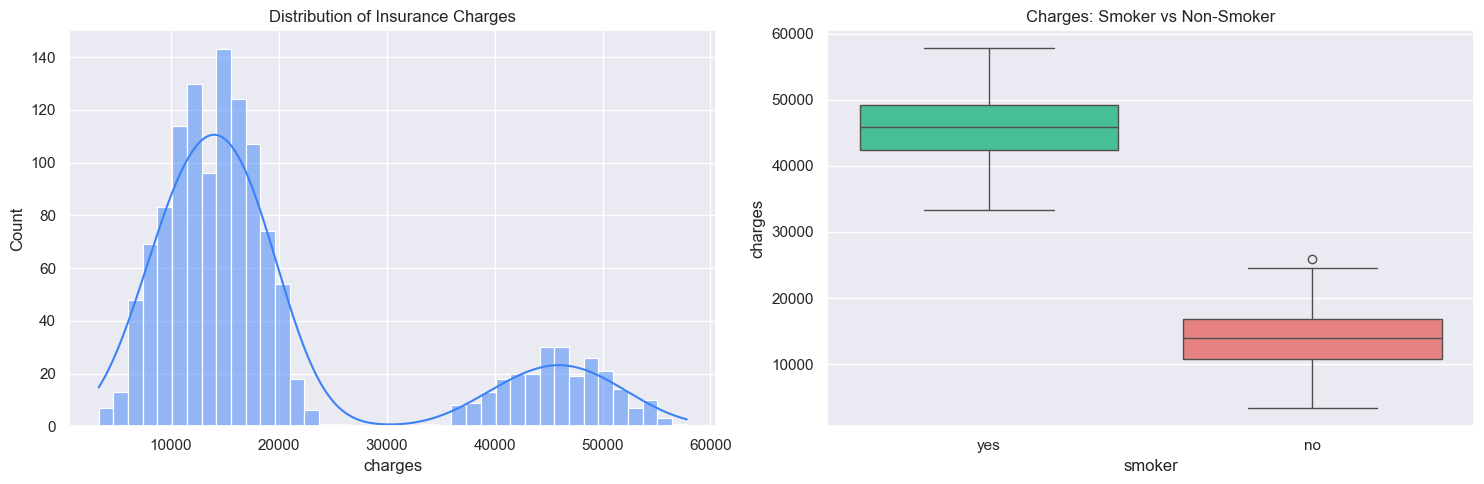

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["charges"], bins=40, kde=True, ax=axes[0], color="#3b82f6")
axes[0].set_title("Distribution of Insurance Charges")

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[1], palette=["#34d399", "#f87171"])
axes[1].set_title("Charges: Smoker vs Non-Smoker")

plt.tight_layout()
plt.show()


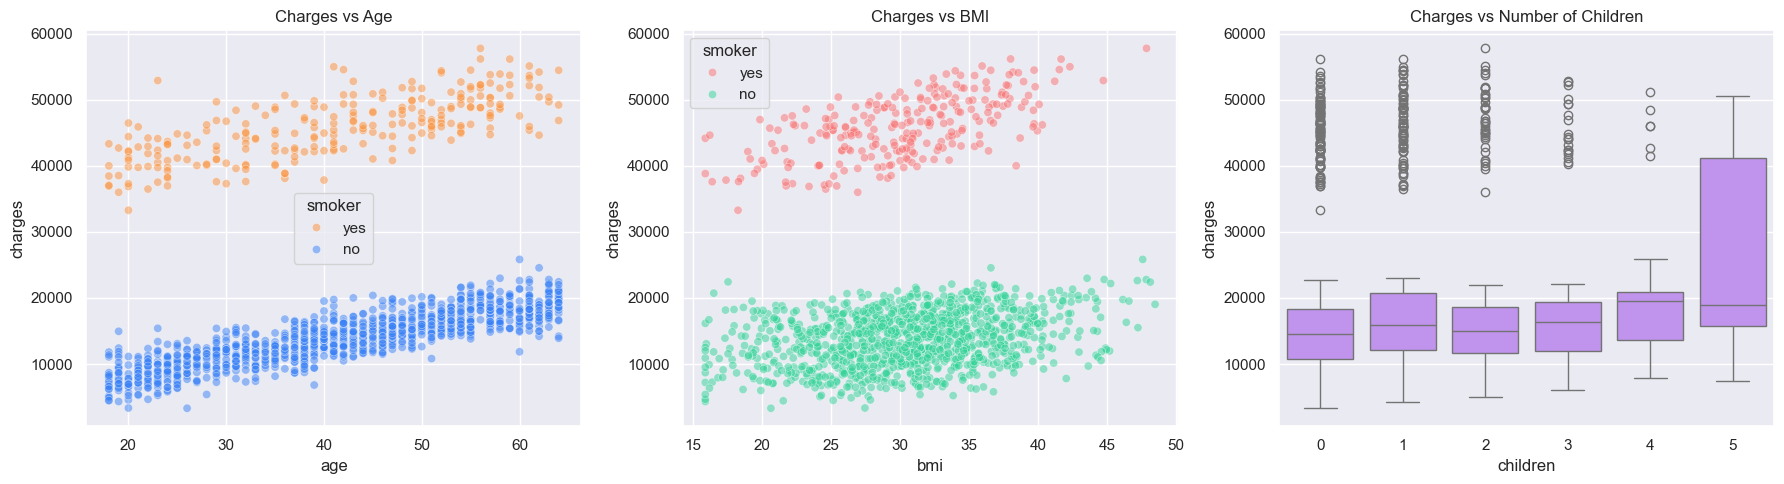

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="age", y="charges", hue="smoker",
                 palette={"no": "#3b82f6", "yes": "#fb923c"}, alpha=0.5, ax=axes[0])
axes[0].set_title("Charges vs Age")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker",
                 palette={"no": "#34d399", "yes": "#f87171"}, alpha=0.5, ax=axes[1])
axes[1].set_title("Charges vs BMI")

sns.boxplot(data=df, x="children", y="charges", ax=axes[2], color="#c084fc")
axes[2].set_title("Charges vs Number of Children")

plt.tight_layout()
plt.show()


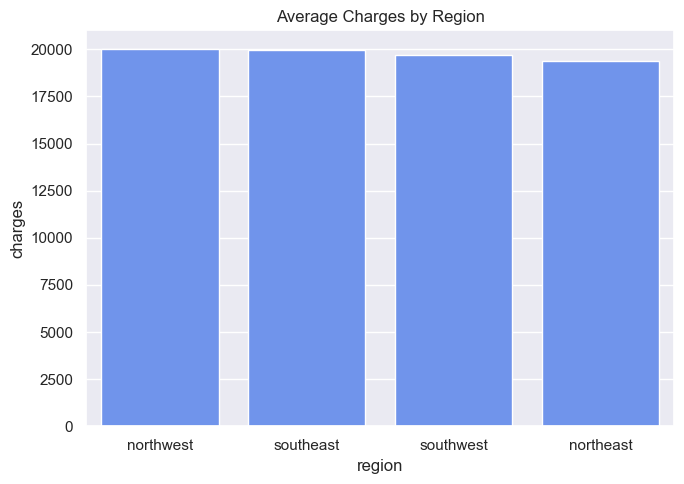

In [11]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="region", y="charges", errorbar=None, color="#5b8cff")
plt.title("Average Charges by Region")
plt.tight_layout()
plt.show()


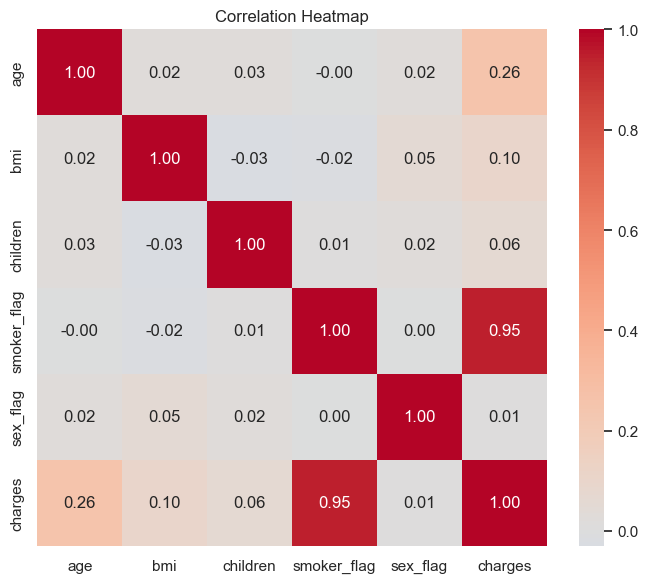

In [12]:
numeric_df = df.copy()
numeric_df["smoker_flag"] = (numeric_df["smoker"] == "yes").astype(int)
numeric_df["sex_flag"] = (numeric_df["sex"] == "male").astype(int)

corr = numeric_df[["age", "bmi", "children", "smoker_flag", "sex_flag", "charges"]].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Key observations:**
- Smoking status has by far the strongest relationship with charges.
- Higher BMI amplifies costs further, especially combined with smoking.
- Age has a steady, moderate positive correlation with charges.
- Region and sex have comparatively small effects.


## 3. Preprocessing & train/test split

In [13]:
categorical_features = ["sex", "smoker", "region"]
numeric_features = ["age", "bmi", "children"]

X = df[numeric_features + categorical_features]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 1070, Test size: 268


## 4. Build and train the model pipeline

In [14]:
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)],
    remainder="passthrough",
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=4,
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## 5. Evaluate the model

In [15]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² score:  {r2:.4f}")
print(f"MAE:       ${mae:,.2f}")
print(f"RMSE:      ${rmse:,.2f}")


R² score:  0.9827
MAE:       $1,345.30
RMSE:      $1,687.85


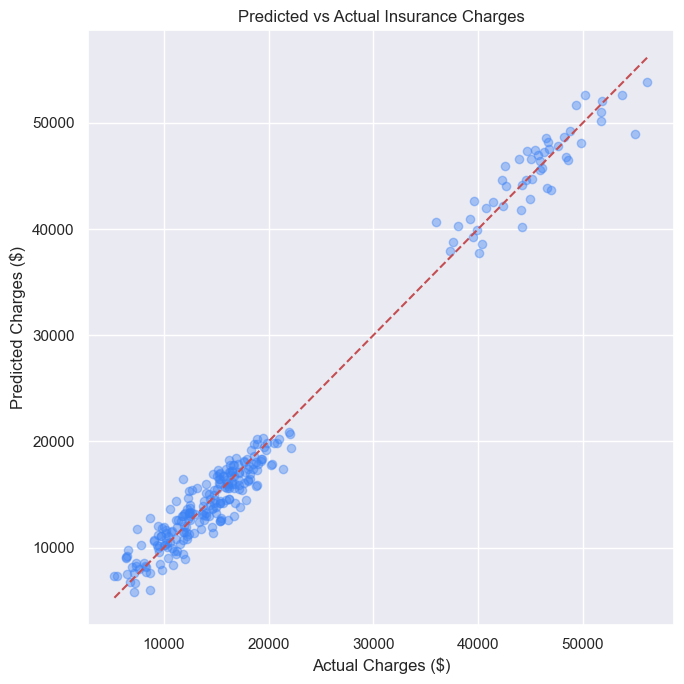

In [16]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color="#3b82f6")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Predicted vs Actual Insurance Charges")
plt.tight_layout()
plt.show()


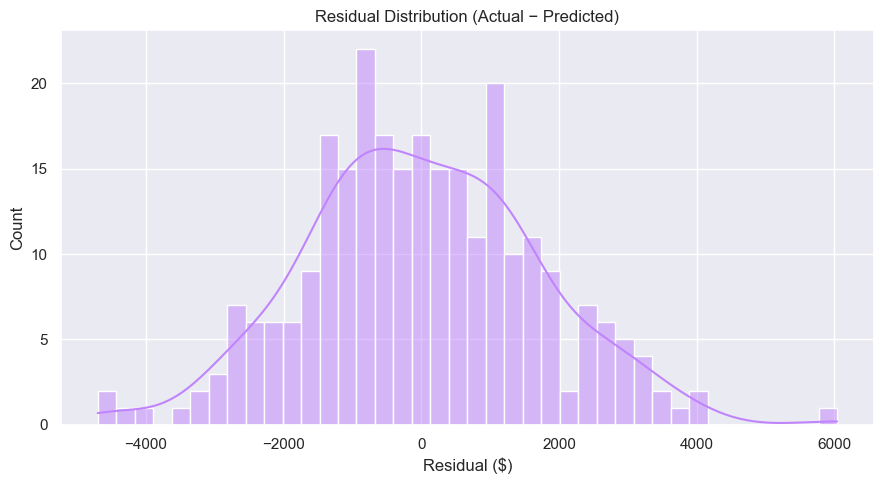

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=40, kde=True, color="#c084fc")
plt.title("Residual Distribution (Actual − Predicted)")
plt.xlabel("Residual ($)")
plt.tight_layout()
plt.show()


## 6. Feature importance

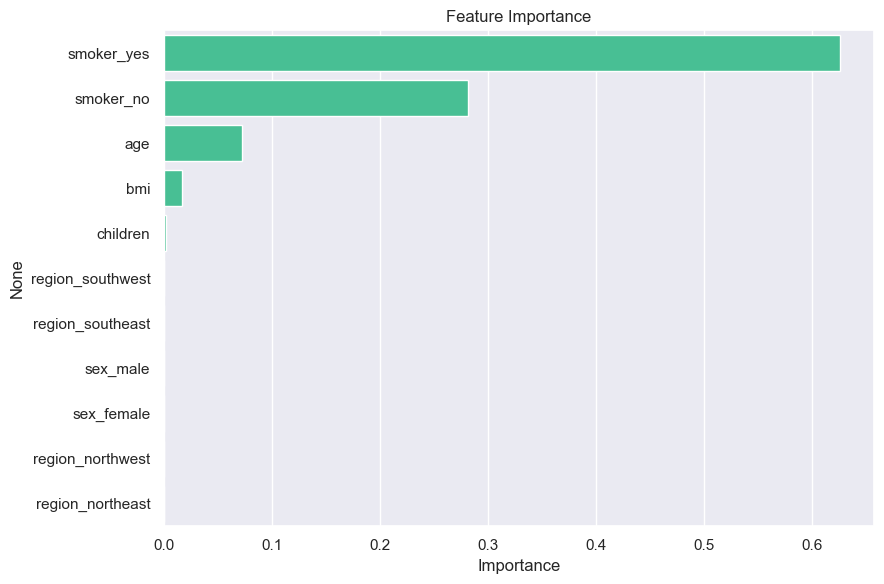

In [18]:
feature_names = (
    list(model.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features))
    + numeric_features
)
importances = pd.Series(model.named_steps["regressor"].feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, color="#34d399")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 7. Sample predictions

In [19]:
samples = pd.DataFrame({
    "age":      [35, 35, 60, 22],
    "sex":      ["male", "male", "female", "female"],
    "bmi":      [32.0, 32.0, 24.5, 21.0],
    "children": [2, 2, 0, 0],
    "smoker":   ["yes", "no", "no", "no"],
    "region":   ["southeast", "southeast", "northwest", "southwest"],
})

samples["predicted_charges"] = model.predict(samples).round(2)
samples


,age,sex,bmi,children,smoker,region,predicted_charges
0,35,male,32.0,2,yes,southeast,44397.53
1,35,male,32.0,2,no,southeast,12885.85
2,60,female,24.5,0,no,northwest,16672.01
3,22,female,21.0,0,no,southwest,6895.16


## 8. Save the trained model

In [21]:
with open("insurance_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved to: model/insurance_model.pkl")


Model saved to: model/insurance_model.pkl


---
## Summary

| Item | Value |
|---|---|
| Algorithm | Random Forest Regressor (300 trees, max depth 8) |
| Features | age, sex, bmi, children, smoker, region |
| Target | charges (USD/year) |
| R² (test) | see output above |
| MAE (test) | see output above |

The saved `model/insurance_model.pkl` is loaded directly by `app.py` (Streamlit UI) for
live predictions.

✨ *Built with AI (Claude).*
